In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 90.7 MB/s eta 0:00:00:00:0100:01


In [2]:
import pennylane as qml
import torch
from torch import nn

torch.manual_seed(42)
torch.set_num_threads(30)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
N_WIRES = 6
N_LAYERS = 5

X_COLLOC_POINTS = 50
Y_COLLOC_POINTS = 50
BOUNDARY_SCALE = 10e1

NEURONS_FNN = 10

REYNOLDS_NUMBER = 10.0

In [4]:
from itertools import product

domain_bounds = torch.tensor([[0.0, 0.0], [1.0, 1.0]], device=device)
x = torch.linspace(0.0, 1.0, X_COLLOC_POINTS)
y = torch.linspace(0.0, 1.0, Y_COLLOC_POINTS)
input_domain = torch.tensor(list(product(x, y)))

input_domain.shape


torch.Size([2500, 2])

In [5]:
lid_boundary_mask = input_domain[:, 1] == 1.0
lid_boundary_colloc = input_domain[lid_boundary_mask]

no_slip_boundary_mask = (
      (input_domain[:, 0] == 0.0)
    | (input_domain[:, 0] == 1.0)
    | (input_domain[:, 1] == 0.0) & (input_domain[:, 1] != 1.0)
)
no_slip_boundary_colloc = input_domain[no_slip_boundary_mask]

boundary_mask = no_slip_boundary_mask | lid_boundary_mask

interior_colloc = input_domain[~boundary_mask]

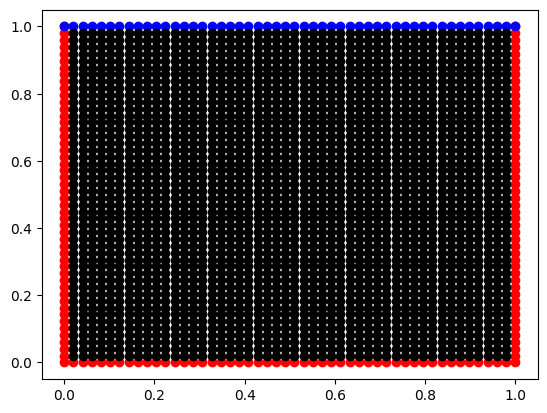

In [6]:
import matplotlib.pyplot as plt

plt.scatter(no_slip_boundary_colloc[:,0],no_slip_boundary_colloc[:,1], c="r")
plt.scatter(lid_boundary_colloc[:,0],lid_boundary_colloc[:,1], c="blue")
plt.scatter(interior_colloc[:,0],interior_colloc[:,1], c="black")
plt.show()

In [7]:
def convert_to_device(*args):
    return [arg.clone().detach().requires_grad_(True).to(device) for arg in args]


input_domain, no_slip_boundary_colloc, lid_boundary_colloc, interior_colloc = (
    convert_to_device(
        input_domain, no_slip_boundary_colloc, lid_boundary_colloc, interior_colloc
    )
)

In [8]:
class ModelFFNBasis(torch.nn.Module):
    def __init__(self, domain_bounds, net_width, n_wires, n_layers):
        super().__init__()

        self.net_width = net_width
        self.n_wires = n_wires
        self.n_layers = n_layers

        self.domain_bounds = domain_bounds

        self.sequential_stack = torch.nn.Sequential(
            nn.Linear(2, self.net_width),
            nn.Tanh(),
            nn.Linear(self.net_width, self.net_width),
            nn.Tanh(),
            nn.Linear(self.net_width, self.net_width),
            nn.Tanh(),
            nn.Linear(self.net_width, self.n_wires),
        )

        self.weights = nn.Parameter(
            torch.randn(self.n_layers, self.n_wires, 3, requires_grad=True)
        )

        self.qnode = qml.QNode(
            self.circuit,
            qml.device("default.qubit", wires=self.n_wires),
            interface="torch",
            diff_method="best",
            max_diff=3,
        )

    def forward(self, x):
        x_rescaled = (
            1.9 * (x - domain_bounds[0]) / (domain_bounds[1] - domain_bounds[0]) - 0.95
        )
        all_basis = self.sequential_stack(x_rescaled)
        return self.qnode(x_rescaled.T, all_basis.T)

    def circuit(self, x, basis):
        # Embedding Ansatz
        for i in range(self.n_wires):
            if i % 2 == 0:
                qml.RY(basis[i] * x[0], wires=i)
            else:
                qml.RY(basis[i] * x[1], wires=i)

        # Variational ansatz
        for i in range(self.n_layers):
            for j in range(self.n_wires):
                qml.RX(self.weights[i, j, 0], wires=j) # pyright: ignore[reportArgumentType]
                qml.RY(self.weights[i, j, 1], wires=j) # pyright: ignore[reportArgumentType]
                qml.RZ(self.weights[i, j, 2], wires=j) # pyright: ignore[reportArgumentType]

            for j in range(N_WIRES - 1):
                qml.CNOT(wires=[j, j + 1])

        return qml.expval(qml.sum(*[qml.PauliZ(i) for i in range(self.n_wires)]))


model_p = ModelFFNBasis(domain_bounds, NEURONS_FNN, N_WIRES, N_LAYERS).to(device)
model_stream = ModelFFNBasis(domain_bounds, NEURONS_FNN, N_WIRES, N_LAYERS).to(device)

In [9]:
def model(x):
    output_p = 5*model_p(x)
    output_stream = 5*model_stream(x)

    d_stream = torch.autograd.grad(output_stream, x, grad_outputs=torch.ones_like(output_stream), create_graph=True)[0]
    output_u = d_stream[:, 1]
    output_v = -1.0 * d_stream[:, 0]

    return output_p, output_u, output_v

In [10]:
def no_slip_loss_fnc():
    _, u, v = model(no_slip_boundary_colloc)
    return torch.mean(u**2 + v**2)


def lid_driven_loss_fnc():
    _, u, v = model(lid_boundary_colloc)
    return torch.mean(v**2 + (u - torch.ones_like(u)) ** 2)


def pde_loss_fnc():
    p, u, v = model(interior_colloc)

    grad_out = torch.ones_like(u)
    dp_d = torch.autograd.grad(p, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    dp_dx = dp_d[:, 0]
    dp_dy = dp_d[:, 1]

    du_d = torch.autograd.grad(u, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dx = du_d[:, 0]
    du_dy = du_d[:, 1]

    dv_d = torch.autograd.grad(v, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    dv_dx = dv_d[:, 0]
    dv_dy = dv_d[:, 1]

    du_dxd = torch.autograd.grad(du_dx, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dxdx = du_dxd[:, 0]
    du_dyd = torch.autograd.grad(du_dy, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dydy = du_dyd[:, 1]

    dv_dxd = torch.autograd.grad(dv_dx, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    dv_dxdx = dv_dxd[:, 0]
    dv_dyd = torch.autograd.grad(dv_dy, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    dv_dydy = dv_dyd[:, 1]

    res_mom_x = u * du_dx + v * du_dy + dp_dx - 1 / REYNOLDS_NUMBER * (du_dxdx + du_dydy)
    res_mom_y = u * dv_dx + v * dv_dy + dp_dy - 1 / REYNOLDS_NUMBER * (dv_dxdx + dv_dydy)

    return torch.mean(res_mom_x**2 + res_mom_y**2)


def reference_loss_fnc():
    p, _, _ = model(torch.tensor([[0.0, 0.0]], device=device, requires_grad=True))
    return torch.mean(p**2)


In [11]:
def loss_fnc():
    no_slip_loss = no_slip_loss_fnc()
    lid_driven_loss = lid_driven_loss_fnc()
    pde_loss = pde_loss_fnc()

    p_ref_loss = reference_loss_fnc()
    return BOUNDARY_SCALE * (no_slip_loss + lid_driven_loss+ p_ref_loss) + pde_loss


In [12]:
opt = torch.optim.LBFGS([*model_p.parameters(), *model_stream.parameters()], line_search_fn="strong_wolfe")


def closure():
    opt.zero_grad()
    l = loss_fnc()
    l.backward()
    return l

In [13]:
fig = plt.figure(figsize=(10, 5), layout="constrained")
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax2 = fig.add_subplot(gs[:, 2])
fig.suptitle(f"LDC Testcase NS + Stream Function", fontsize=18)

ax0.set_title("Pressure")
ax1.set_title("Velocity Magnitude")
ax3.set_title("U Velocity")
ax4.set_title("V Velocity")

ax0.set_aspect("equal", "box")
ax1.set_aspect("equal", "box")
ax3.set_aspect("equal", "box")
ax4.set_aspect("equal", "box")

p, u, v = model(input_domain)
X, Y = torch.meshgrid(x, y)

cs0 = ax0.contourf(
    X,
    Y,
    p.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="Spectral",
)
cb0 = plt.colorbar(cs0, ax=ax0)
cs1 = ax1.contourf(
    X,
    Y,
    torch.sqrt(
        u.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu() ** 2
        + v.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu() ** 2
    ),
    400,
    cmap="plasma",
)
cb1 = plt.colorbar(cs1, ax=ax1)
cs3 = ax3.contourf(
    X,
    Y,
    u.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="plasma",
)
cb3 = plt.colorbar(cs3, ax=ax3)
cs4 = ax4.contourf(
    X,
    Y,
    v.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="plasma",
)
cb4 = plt.colorbar(cs4, ax=ax4)

ax2.plot(loss_hist, label="Loss QPINN")
ax2.set_yscale("log")
ax2.grid()
ax2.legend(loc="upper right")

plt.show()import datetime

loss_hist = []

for i in range(10):
    start = datetime.datetime.now()
    opt.step(closure)

    loss_hist.append(loss_fnc().detach().cpu().numpy())

    print(f"Iteration: {i} | Loss: {loss_hist[-1]:.8e}")
    print(f"\t Iteration duration: {(datetime.datetime.now()-start).total_seconds()}")


Iteration: 0 | Loss: 8.58335850e+00
	 Iteration duration: 248.187183
Iteration: 1 | Loss: 6.10643462e+00
	 Iteration duration: 257.45787
Iteration: 2 | Loss: 5.08308836e+00
	 Iteration duration: 245.932246
Iteration: 3 | Loss: 4.28443036e+00
	 Iteration duration: 257.892716
Iteration: 4 | Loss: 4.14230986e+00
	 Iteration duration: 246.138092
Iteration: 5 | Loss: 4.02071178e+00
	 Iteration duration: 269.220761
Iteration: 6 | Loss: 3.89653395e+00
	 Iteration duration: 246.136685
Iteration: 7 | Loss: 3.81054117e+00
	 Iteration duration: 268.951951
Iteration: 8 | Loss: 3.71005881e+00
	 Iteration duration: 257.542878
Iteration: 9 | Loss: 3.64927003e+00
	 Iteration duration: 269.277122


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


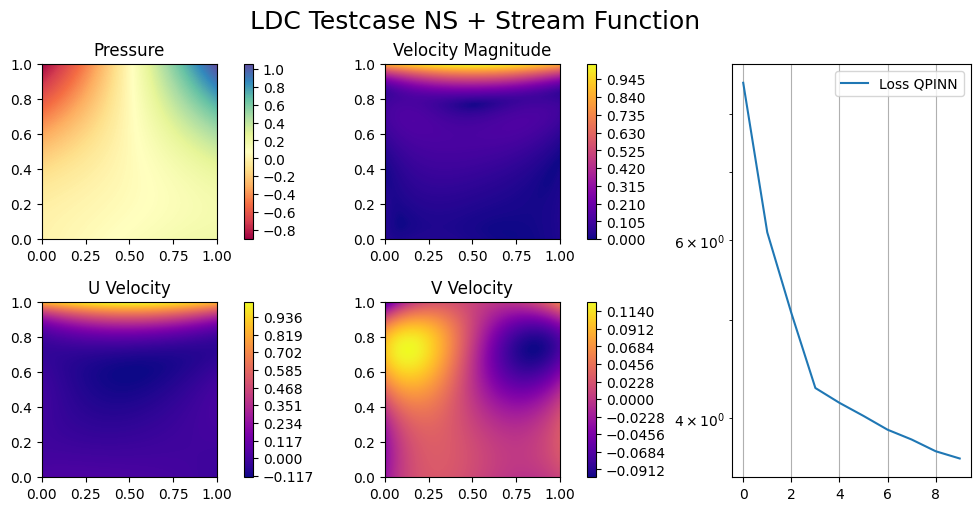

In [14]:
fig = plt.figure(figsize=(10, 5), layout="constrained")
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax2 = fig.add_subplot(gs[:, 2])
fig.suptitle(f"LDC Testcase NS + Stream Function", fontsize=18)

ax0.set_title("Pressure")
ax1.set_title("Velocity Magnitude")
ax3.set_title("U Velocity")
ax4.set_title("V Velocity")

ax0.set_aspect("equal", "box")
ax1.set_aspect("equal", "box")
ax3.set_aspect("equal", "box")
ax4.set_aspect("equal", "box")

p, u, v = model(input_domain)
X, Y = torch.meshgrid(x, y)

cs0 = ax0.contourf(
    X,
    Y,
    p.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="Spectral",
)
cb0 = plt.colorbar(cs0, ax=ax0)
cs1 = ax1.contourf(
    X,
    Y,
    torch.sqrt(
        u.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu() ** 2
        + v.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu() ** 2
    ),
    400,
    cmap="plasma",
)
cb1 = plt.colorbar(cs1, ax=ax1)
cs3 = ax3.contourf(
    X,
    Y,
    u.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="plasma",
)
cb3 = plt.colorbar(cs3, ax=ax3)
cs4 = ax4.contourf(
    X,
    Y,
    v.reshape(X_COLLOC_POINTS, Y_COLLOC_POINTS).detach().cpu(),
    400,
    cmap="plasma",
)
cb4 = plt.colorbar(cs4, ax=ax4)

ax2.plot(loss_hist, label="Loss QPINN")
ax2.set_yscale("log")
ax2.grid()
ax2.legend(loc="upper right")

plt.show()

In [16]:
x_red = torch.linspace(0.0, 1.0, 50, requires_grad=True)
y_red = torch.linspace(0.0, 1.0, 50, requires_grad=True)
input_domain_red = torch.tensor(
    list(product(x_red, y_red)), device=device, requires_grad=True
)

# p, u, v = model(input_domain_red)
# print("x y u v u_mag p")
# for i in range(input_domain_red.shape[0]):
#     print(
#         f"{input_domain_red[i,0].item()} {input_domain_red[i,1].item()} {u[i].item()} {v[i].item()} {torch.sqrt(u[i]**2 + v[i]**2).item()} {p[i].item()}"
#     )

print("idx loss_hist")
for i in range(len(loss_hist)):
    print(f"{i} {loss_hist[i]}")

idx loss_hist
0 8.583358500883735
1 6.106434620138514
2 5.08308835802353
3 4.284430362332069
4 4.142309855677165
5 4.020711780955802
6 3.896533953912922
7 3.8105411719688282
8 3.7100588069836204
9 3.6492700268413585
